# Tests of the sliding diffusion concept

The following with be experiements and tests of hyperparameter configurations, sometimes with numerical evalusaions, and prints for analasis. 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from local_attention import transformer
from local_attention.rotary import SinusoidalEmbeddings, apply_rotary_pos_emb
import matplotlib.pyplot as plt
from typing import Union
from io import BytesIO
from PIL import Image
from moviepy import ImageSequenceClip
from datetime import datetime
from v1_sliding_diffusion import Diffusion

import wandb

In [2]:
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: pefu (pefu-it-university-of-copenhagen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu")

self.time_step_stackings [(tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9932, 0.9798, 0.9599, 0.9339,
        0.9021, 0.8652, 0.8238, 0.7785, 0.7303, 0.6798, 0.6279, 0.5755, 0.5232,
        0.4718, 0.4220, 0.3742, 0.3291, 0.2869, 0.2479, 0.2123, 0.1801, 0.1514,
        0.1261, 0.1039, 0.0849, 0.0686, 0.0549, 0.0434, 0.0340, 0.0264, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000]), tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0

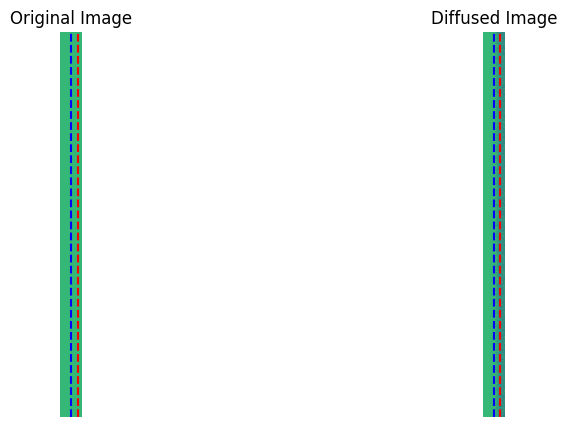

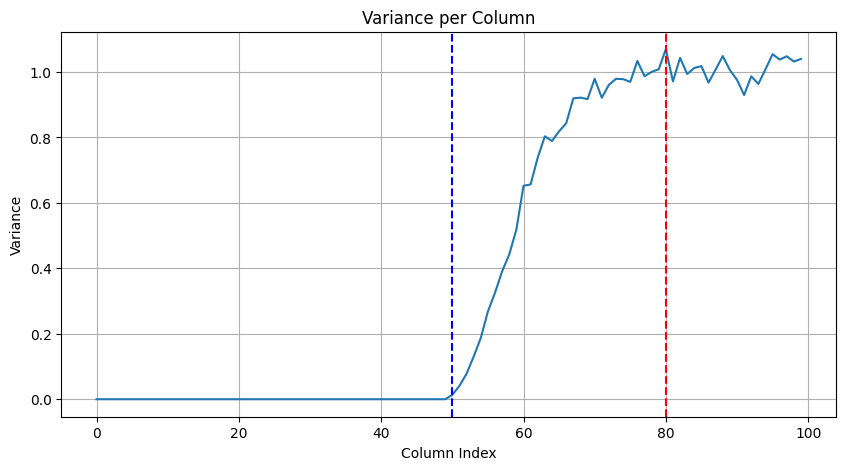

In [4]:
# Initialize the diffusion class
diffusion = Diffusion(
        num_of_pre_timestep_frames = 50, 
        num_of_timestep_frames = 30, 
        num_of_post_timestep_frames = 20, 
        noise_schedule = Diffusion.linear_schedule(0.0002, 0.40), 
        device = device 
    )

# Create a tensor that is all white so we can see the noising process removing details
image = torch.ones((177 * 10, 100))
image = image.to(device)

# Run the forward diffusion function
transformed_image = diffusion.forward(seqence_tensor = image)

# Draw both images next to each other in the python notebook
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image.cpu().numpy(), vmin=-3, vmax=3)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_image.cpu().numpy(), vmin=-3, vmax=3)
ax[1].set_title("Diffused Image")
ax[1].axis("off")

# Draw a vertical line at num_of_pre_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

# Draw a vertical line at num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames + diffusion.num_of_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='red', linestyle='--', label='Timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

plt.show()

# Calculate the variance per frame (vertical slice)
variances = torch.var(transformed_image, dim=0)

# Plot the variance for each column
plt.figure(figsize=(10, 5))
plt.plot(variances.cpu().numpy())
plt.title("Variance per Column")
plt.xlabel("Column Index")
plt.ylabel("Variance")
plt.grid(True)

# Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
plt.axvline(x=line_x + diffusion.num_of_timestep_frames, color='red', linestyle='--', label='Timestep frames')


plt.show()

In [5]:
from v1_model import ContinuousMotionModel
from debugger import Debugger
from v1_traing_loop import train
from v1_sliding_diffusion import Diffusion

### Experiment 01

In [6]:
model = ContinuousMotionModel(
        deffsion_noise_scheduler=Diffusion(
            device=device,
            num_of_pre_timestep_frames=50,
            num_of_timestep_frames=100,
            num_of_post_timestep_frames=0,
            noise_schedule=Diffusion.linear_schedule(0.0002, 0.005)),
        number_of_styles = 17,
        n_gesture_length = 150,
        audio_features_per_frame = 804,
        pose_features_per_frame = 345,
        number_of_attention_heads = 8,
        debugger = Debugger(
            on=True, 
            keys_for_printing_while_running=["ALL"]
        ),
        device=device,
)

self.time_step_stackings [(tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 0.9997, 0.9996, 0.9994,
        0.9991, 0.9989, 0.9986, 0.9983, 0.9980, 0.9977, 0.9973, 0.9969, 0.9965,
        0.9961, 0.9956, 0.9951, 0.9946, 0.9941, 0.9936, 0.9930, 0.9924, 0.9918,
        0.9911, 0.9904, 0.9897, 0.9890, 0.9883, 0.9875, 0.9867, 0.9859, 0.9851,
        0.9842, 0.9834, 0.9825, 0.9815, 0.9806, 0.9796, 0.9786, 0.9776, 0.9766,
        0.9755, 0.9744, 0.9733, 0.9722, 0.9711, 0.9699, 0.9687, 0.9675, 0.9663,
        0.9650, 0.9637, 0.9624, 0.9611, 0.9598, 0.9584, 0.9570, 0.9556, 0.9542,
        0.952

In [7]:
num_of_timestap_stackings = 2
time_step_stacking_indexs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
num_of_timestep_frames = 4

for time_step_stacking_index in time_step_stacking_indexs:
    timesteps_at_frames = [(t + 1) * num_of_timestap_stackings - (time_step_stacking_index % num_of_timestap_stackings) for t in range(num_of_timestep_frames)]
    print(timesteps_at_frames, " with size: ", len(timesteps_at_frames), " must be equal to: ", num_of_timestep_frames)  
    

[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4


In [8]:
from torch.utils.data import DataLoader
from dataset.dataset import *

train(
    debug_run=True,
    experiment_collection_name="first_tests",
    model=model,
    device=device,
    training_loader=DataLoader(
            ConsolidatedRAMDataset(
                consolidated_file= "dataset/genea2023_dataset/trn/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
                seq_length=150,
                seed_length=8,
                batch_size=10,
                epoch_length=1
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = True
        ),
    val_loader=None, 
    num_epochs=1)

Found 14889 valid starting points for windows
Model compling to cudagraphs runtime


Epoch 1/1:   0%|          | 0/1 [00:00<?, ?it/s]


TypeError: ContinuousMotionModel.forward() missing 1 required positional argument: 'current_noise_stacking_level'

one_hot_style  max value:  tensor(1., dtype=torch.float16)
one_hot_style  min value:  tensor(0., dtype=torch.float16)
audio_features  max value:  tensor(24.4688, dtype=torch.float16)
audio_features  min value:  tensor(-15.3047, dtype=torch.float16)
noisy_gesture_sequence  max value:  tensor(1.7475)
noisy_gesture_sequence  min value:  tensor(-2.0957)
timestep_0_pos_embedding  max value:  tensor(0.0064, dtype=torch.bfloat16, grad_fn=<MaxBackward1>)
timestep_0_pos_embedding  min value:  tensor(-0.0050, dtype=torch.bfloat16, grad_fn=<MinBackward1>)


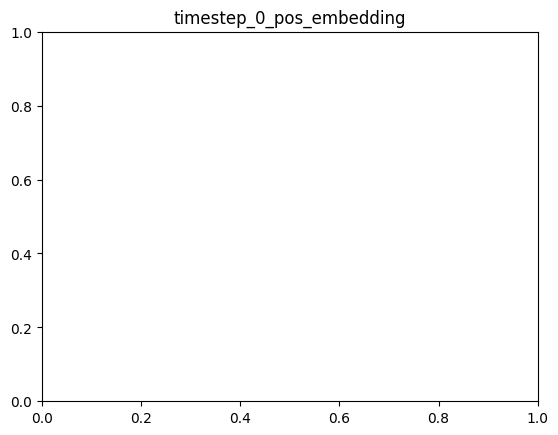

timestep_max_pos_embedding  max value:  tensor(0.4121, dtype=torch.bfloat16, grad_fn=<MaxBackward1>)
timestep_max_pos_embedding  min value:  tensor(-0.4922, dtype=torch.bfloat16, grad_fn=<MinBackward1>)


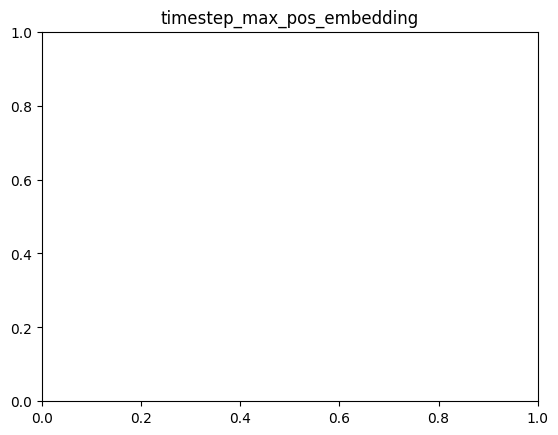

t_for_each_timestep_frame  max value:  tensor(0.9900)
t_for_each_timestep_frame  min value:  tensor(0.)


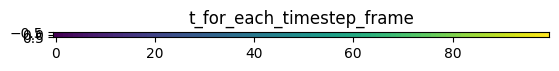

t_with_pos_embedding_for_each_timestep_frame - should be (t_for_each_timestep_frame, 192)  max value:  tensor(0.6875, dtype=torch.bfloat16, grad_fn=<MaxBackward1>)
t_with_pos_embedding_for_each_timestep_frame - should be (t_for_each_timestep_frame, 192)  min value:  tensor(-0.7109, dtype=torch.bfloat16, grad_fn=<MinBackward1>)


TypeError: Got unsupported ScalarType BFloat16

In [ ]:
model.debugger.get_available_keys()
model.debugger.print_from_key("ALL")
